# Implement Simple and Multiple Linear Regression Models

#### 1. Load the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../ML Data.csv', dtype={'ROLL NO.': str})
df.columns = df.columns.str.strip()  # remove stray leading/trailing spaces from headers
print(df.head())
print(df.shape)

       ROLL NO. GENDER  SOFTWARE ENGINEER   TOC  COMPUTER NETWORK  \
0  240104010001      M               30.0  30.0              30.0   
1  240104010002      F               30.0  40.0              45.0   
2  240104010003      M               38.0  38.0              38.0   
3  240104010004      M               59.0  55.0              57.0   
4  240104010005      M               30.0  30.0              30.0   

   MACHINE LEARNING  DATA WAREHOUSE GRADE RESULT  
0              30.0            30.0     C   PASS  
1              40.0            35.0     B   Pass  
2              38.0            38.0     B   Pass  
3              58.0            54.0     A   pass  
4              30.0            30.0     C   Pass  
(86, 9)


#### 2. Clean the data

In [2]:
numeric_cols = ['SOFTWARE ENGINEER', 'TOC', 'COMPUTER NETWORK', 'MACHINE LEARNING', 'DATA WAREHOUSE']

df['GENDER'] = df['GENDER'].str.strip().str.upper()
df['RESULT'] = df['RESULT'].str.strip().str.upper()
df['GRADE'] = df['GRADE'].str.strip().str.upper()

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

for col in ['GENDER', 'RESULT', 'GRADE']:
    df[col] = df[col].fillna(df[col].mode()[0])

df = df.dropna(subset=['ROLL NO.'])
print(df.isnull().sum())

ROLL NO.             0
GENDER               0
SOFTWARE ENGINEER    0
TOC                  0
COMPUTER NETWORK     0
MACHINE LEARNING     0
DATA WAREHOUSE       0
GRADE                0
RESULT               0
dtype: int64


## Part A: Simple Linear Regression
Predict **MACHINE LEARNING** marks using a single feature, **TOC** marks.

#### 3. Define X and y (single feature)

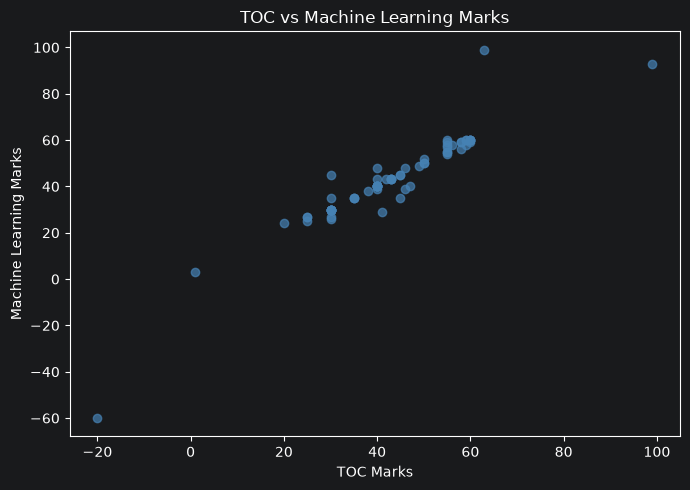

In [3]:
X_simple = df[['TOC']]
y_simple = df['MACHINE LEARNING']

plt.figure(figsize=(7, 5))
plt.scatter(X_simple, y_simple, color='steelblue', alpha=0.7)
plt.xlabel('TOC Marks')
plt.ylabel('Machine Learning Marks')
plt.title('TOC vs Machine Learning Marks')
plt.tight_layout()
plt.show()

#### 4. Train-test split

In [4]:
from sklearn.model_selection import train_test_split

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y_simple, test_size=0.2, random_state=42
)

print("Train shape:", X_train_s.shape)
print("Test shape:", X_test_s.shape)

Train shape: (56, 1)
Test shape: (15, 1)


#### 5. Fit the Simple Linear Regression model

In [5]:
from sklearn.linear_model import LinearRegression

simple_model = LinearRegression()
simple_model.fit(X_train_s, y_train_s)

print(f"Intercept: {simple_model.intercept_:.4f}")
print(f"Coefficient (TOC): {simple_model.coef_[0]:.4f}")
print(f"Equation: MACHINE LEARNING = {simple_model.intercept_:.2f} + {simple_model.coef_[0]:.2f} * TOC")

Intercept: 2.4541
Coefficient (TOC): 0.9521
Equation: MACHINE LEARNING = 2.45 + 0.95 * TOC


#### 6. Evaluate the Simple Linear Regression model

In [6]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred_s = simple_model.predict(X_test_s)

mae_s = mean_absolute_error(y_test_s, y_pred_s)
mse_s = mean_squared_error(y_test_s, y_pred_s)
rmse_s = np.sqrt(mse_s)
r2_s = r2_score(y_test_s, y_pred_s)

print(f"MAE:  {mae_s:.4f}")
print(f"MSE:  {mse_s:.4f}")
print(f"RMSE: {rmse_s:.4f}")
print(f"R2 Score: {r2_s:.4f}")

MAE:  6.7996
MSE:  223.3339
RMSE: 14.9444
R2 Score: 0.7703


#### 7. Visualize the regression line

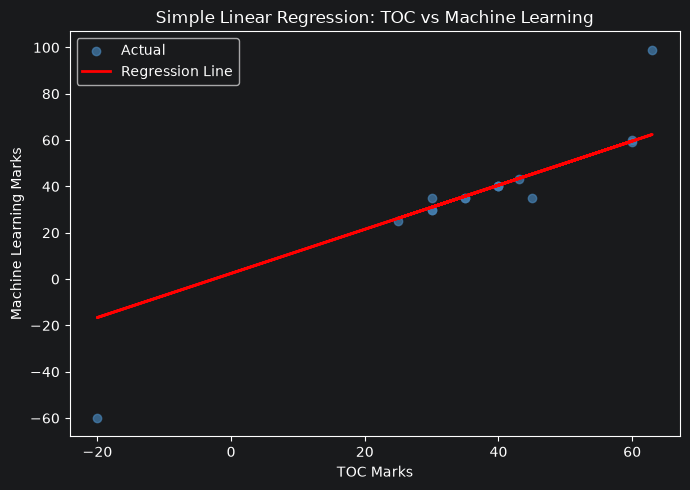

In [7]:
plt.figure(figsize=(7, 5))
plt.scatter(X_test_s, y_test_s, color='steelblue', alpha=0.7, label='Actual')
plt.plot(X_test_s, y_pred_s, color='red', linewidth=2, label='Regression Line')
plt.xlabel('TOC Marks')
plt.ylabel('Machine Learning Marks')
plt.title('Simple Linear Regression: TOC vs Machine Learning')
plt.legend()
plt.tight_layout()
plt.show()

## Part B: Multiple Linear Regression
Predict **MACHINE LEARNING** marks using all the other subject scores as features.

#### 8. Define X and y (multiple features)

In [8]:
features = ['SOFTWARE ENGINEER', 'TOC', 'COMPUTER NETWORK', 'DATA WAREHOUSE']

X_multi = df[features]
y_multi = df['MACHINE LEARNING']

X_multi.head()

,SOFTWARE ENGINEER,TOC,COMPUTER NETWORK,DATA WAREHOUSE
0,30.0,30.0,30.0,30.0
1,30.0,40.0,45.0,35.0
2,38.0,38.0,38.0,38.0
3,59.0,55.0,57.0,54.0
4,30.0,30.0,30.0,30.0


#### 9. Train-test split


In [9]:
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42
)

print("Train shape:", X_train_m.shape)
print("Test shape:", X_test_m.shape)

Train shape: (56, 4)
Test shape: (15, 4)


#### 10. Fit the Multiple Linear Regression model

In [10]:
multi_model = LinearRegression()
multi_model.fit(X_train_m, y_train_m)

print(f"Intercept: {multi_model.intercept_:.4f}")
for feature, coef in zip(features, multi_model.coef_):
    print(f"Coefficient ({feature}): {coef:.4f}")

Intercept: 3.1719
Coefficient (SOFTWARE ENGINEER): -0.1205
Coefficient (TOC): 0.7542
Coefficient (COMPUTER NETWORK): 0.3079
Coefficient (DATA WAREHOUSE): -0.0061


#### 11. Evaluate the Multiple Linear Regression model

In [11]:
y_pred_m = multi_model.predict(X_test_m)

mae_m = mean_absolute_error(y_test_m, y_pred_m)
mse_m = mean_squared_error(y_test_m, y_pred_m)
rmse_m = np.sqrt(mse_m)
r2_m = r2_score(y_test_m, y_pred_m)

print(f"MAE:  {mae_m:.4f}")
print(f"MSE:  {mse_m:.4f}")
print(f"RMSE: {rmse_m:.4f}")
print(f"R2 Score: {r2_m:.4f}")

MAE:  7.0760
MSE:  226.6166
RMSE: 15.0538
R2 Score: 0.7669


#### 12. Actual vs Predicted plot

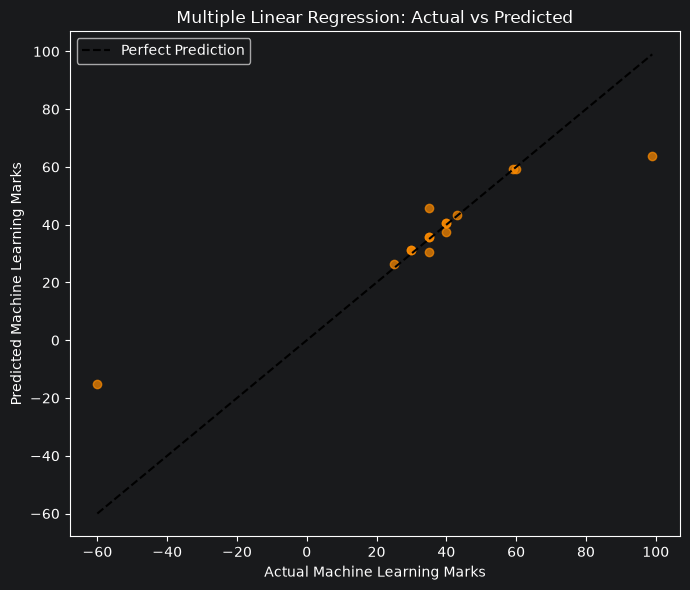

In [12]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test_m, y_pred_m, color='darkorange', alpha=0.7)
plt.plot([y_test_m.min(), y_test_m.max()], [y_test_m.min(), y_test_m.max()],
         color='black', linestyle='--', label='Perfect Prediction')
plt.xlabel('Actual Machine Learning Marks')
plt.ylabel('Predicted Machine Learning Marks')
plt.title('Multiple Linear Regression: Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()

#### 13. Compare Simple vs Multiple Regression performance

In [13]:
comparison = pd.DataFrame({
    'Model': ['Simple Linear Regression (TOC only)', 'Multiple Linear Regression (all subjects)'],
    'MAE': [mae_s, mae_m],
    'RMSE': [rmse_s, rmse_m],
    'R2 Score': [r2_s, r2_m]
})
comparison

,Model,MAE,RMSE,R2 Score
0,Simple Linear Regression (TOC only),6.799567,14.944361,0.770295
1,Multiple Linear Regression (all subjects),7.075952,15.053790,0.766919
